In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn gradio

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
np.random.seed(42)

n = 1000

df = pd.DataFrame({
    "Rainfall_mm": np.random.uniform(20, 300, n),
    "Soil_Moisture": np.random.uniform(10, 95, n),
    "Slope_Degree": np.random.uniform(5, 60, n),
    "Elevation_m": np.random.uniform(50, 2500, n),
    "Temperature_C": np.random.uniform(5, 40, n),
    "Distance_From_River_m": np.random.uniform(10, 2000, n),
    "Vegetation_Index": np.random.uniform(0.1, 0.9, n)
     })

df.head()

,Rainfall_mm,Soil_Moisture,Slope_Degree,Elevation_m,Temperature_C,Distance_From_River_m,Vegetation_Index
0,124.871233,25.736299,19.393813,1698.122336,25.019856,793.334685,0.618606
1,286.200006,56.061581,18.583834,2001.869423,33.190132,952.136962,0.237909
2,224.958304,84.200396,54.844002,663.646352,31.605633,1710.549312,0.797916
3,187.624376,72.239115,18.725041,1580.941544,10.386497,686.608728,0.590493
4,63.685219,78.557698,19.957235,1450.777659,10.223731,1740.602873,0.225763


In [5]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 1000

df = pd.DataFrame({"Rainfall_mm": np.random.uniform(20, 300, n), "Soil_Moisture": np.random.uniform(10, 95, n), "Slope_Degree": np.random.uniform(5, 60, n), "Elevation_m": np.random.uniform(50, 2500, n), "Temperature_C": np.random.uniform(5, 40, n), "Distance_From_River_m": np.random.uniform(10, 2000, n), "Vegetation_Index": np.random.uniform(0.1, 0.9, n)})

df.head()

,Rainfall_mm,Soil_Moisture,Slope_Degree,Elevation_m,Temperature_C,Distance_From_River_m,Vegetation_Index
0,124.871233,25.736299,19.393813,1698.122336,25.019856,793.334685,0.618606
1,286.200006,56.061581,18.583834,2001.869423,33.190132,952.136962,0.237909
2,224.958304,84.200396,54.844002,663.646352,31.605633,1710.549312,0.797916
3,187.624376,72.239115,18.725041,1580.941544,10.386497,686.608728,0.590493
4,63.685219,78.557698,19.957235,1450.777659,10.223731,1740.602873,0.225763


In [7]:
risk_score = 0.30*(df["Rainfall_mm"]/300) + 0.25*(df["Soil_Moisture"]/100) + 0.25*(df["Slope_Degree"]/60) + 0.10*(1-df["Vegetation_Index"]) + 0.10*(1-df["Distance_From_River_m"]/2000)
df["Risk_Score"] = risk_score
df.head()

,Rainfall_mm,Soil_Moisture,Slope_Degree,Elevation_m,Temperature_C,Distance_From_River_m,Vegetation_Index,Risk_Score
0,124.871233,25.736299,19.393813,1698.122336,25.019856,793.334685,0.618606,0.368492
1,286.200006,56.061581,18.583834,2001.869423,33.190132,952.136962,0.237909,0.632389
2,224.958304,84.200396,54.844002,663.646352,31.605633,1710.549312,0.797916,0.698657
3,187.624376,72.239115,18.725041,1580.941544,10.386497,686.608728,0.590493,0.552863
4,63.685219,78.557698,19.957235,1450.777659,10.223731,1740.602873,0.225763,0.433628


In [8]:
def classify_risk(score):
      if score < 0.35:
          return "Low"
      elif score < 0.60:
          return "Medium"
      else:
           return "High"
df["Landslide_Risk"] = df["Risk_Score"].apply(classify_risk)
df.head()

,Rainfall_mm,Soil_Moisture,Slope_Degree,Elevation_m,Temperature_C,Distance_From_River_m,Vegetation_Index,Risk_Score,Landslide_Risk
0,124.871233,25.736299,19.393813,1698.122336,25.019856,793.334685,0.618606,0.368492,Medium
1,286.200006,56.061581,18.583834,2001.869423,33.190132,952.136962,0.237909,0.632389,High
2,224.958304,84.200396,54.844002,663.646352,31.605633,1710.549312,0.797916,0.698657,High
3,187.624376,72.239115,18.725041,1580.941544,10.386497,686.608728,0.590493,0.552863,Medium
4,63.685219,78.557698,19.957235,1450.777659,10.223731,1740.602873,0.225763,0.433628,Medium


In [9]:
X = df[
      [
              "Rainfall_mm",
                      "Soil_Moisture",
                              "Slope_Degree",
                                      "Elevation_m",
                                              "Temperature_C",
                                                      "Distance_From_River_m",
                                                              "Vegetation_Index"
                                                                  ]
                                                                  ]
y = df["Landslide_Risk"]
print("Input features:", X.shape)
print("Target:", y.shape)


Input features: (1000, 7)
Target: (1000,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
        y,
            test_size=0.20,
                random_state=42,
                    stratify=y
                    )
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 7)
Testing data: (200, 7)


In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
        random_state=42
        )
model.fit(X_train, y_train)
print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


In [12]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Model Accuracy: 0.885
Accuracy Percentage: 88.5 %


In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.96      0.83      0.89        60
         Low       1.00      0.45      0.62        20
      Medium       0.85      0.98      0.91       120

    accuracy                           0.89       200
   macro avg       0.94      0.76      0.81       200
weighted avg       0.90      0.89      0.88       200



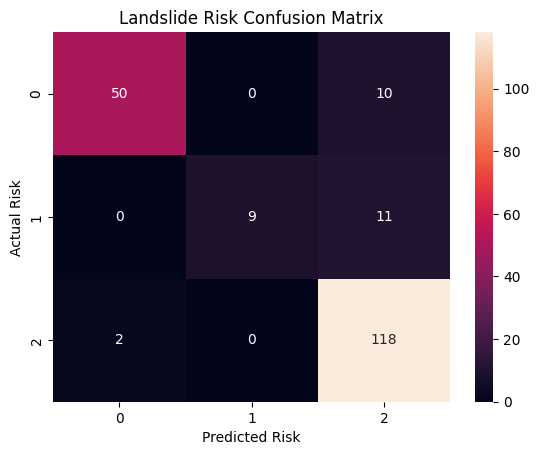

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.title("Landslide Risk Confusion Matrix")

plt.show()

In [19]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
        "Importance": importance
        })

feature_importance = feature_importance.sort_values(
            by="Importance",
                ascending=False
                )

feature_importance

,Feature,Importance
0,Rainfall_mm,0.304588
2,Slope_Degree,0.222067
1,Soil_Moisture,0.176503
5,Distance_From_River_m,0.098944
6,Vegetation_Index,0.080835
3,Elevation_m,0.060817
4,Temperature_C,0.056245


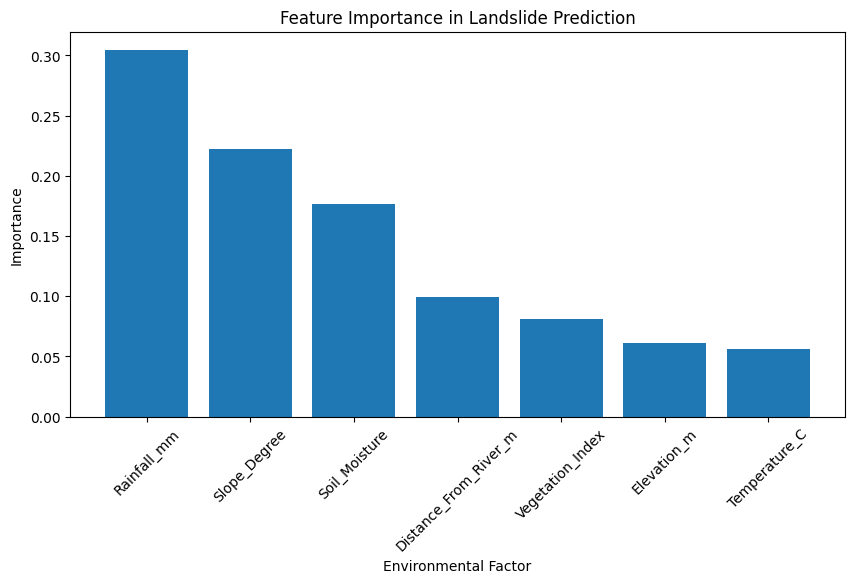

In [20]:
plt.figure(figsize=(10, 5))

plt.bar(
    feature_importance["Feature"],
        feature_importance["Importance"]
        )

plt.xlabel("Environmental Factor")
plt.ylabel("Importance")
plt.title("Feature Importance in Landslide Prediction")

plt.xticks(rotation=45)

plt.show()

In [21]:
new_location = pd.DataFrame({
      "Rainfall_mm": [250],
          "Soil_Moisture": [85],
              "Slope_Degree": [45],
                  "Elevation_m": [1200],
                      "Temperature_C": [22],
                          "Distance_From_River_m": [300],
                              "Vegetation_Index": [0.3]
                              })

prediction = model.predict(new_location)

print("Predicted Landslide Risk:", prediction[0])


Predicted Landslide Risk: High


In [22]:
probabilities = model.predict_proba(new_location)[0]

classes = model.classes_

for risk, probability in zip(classes, probabilities):
    print(risk, ":", round(probability * 100, 2), "%")

High : 95.0 %
Low : 0.0 %
Medium : 5.0 %


In [23]:
!pip install -q gradio

In [24]:
import gradio as gr

In [26]:
predict_landslide = lambda rainfall, soil_moisture, slope, elevation, temperature, distance_river, vegetation: "Predicted Landslide Risk: " + str(model.predict(pd.DataFrame({"Rainfall_mm":[rainfall], "Soil_Moisture":[soil_moisture], "Slope_Degree":[slope], "Elevation_m":[elevation], "Temperature_C":[temperature], "Distance_From_River_m":[distance_river], "Vegetation_Index":[vegetation]}))[0])

In [27]:
print(predict_landslide(250, 85, 45, 1200, 22, 300, 0.3))

Predicted Landslide Risk: High


In [28]:
import gradio as gr

In [29]:
interface = gr.Interface(predict_landslide, [gr.Number(label="Rainfall (mm)"), gr.Number(label="Soil Moisture (%)"), gr.Number(label="Slope (degrees)"), gr.Number(label="Elevation (m)"), gr.Number(label="Temperature (°C)"), gr.Number(label="Distance From River (m)"), gr.Number(label="Vegetation Index")], gr.Textbox(label="Prediction"), title="Landslide Risk Prediction System", description="Enter environmental conditions to predict landslide risk.")

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9241fb1c98871dbf09.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [32]:
interface = gr.Interface(predict_landslide, [gr.Number(label="🌧️ Rainfall (mm)", value=250), gr.Number(label="💧 Soil Moisture (%)", value=85), gr.Number(label="⛰️ Slope (degrees)", value=45), gr.Number(label="📍 Elevation (m)", value=1200), gr.Number(label="🌡️ Temperature (°C)", value=22), gr.Number(label="🌊 Distance From River (m)", value=300), gr.Number(label="🌱 Vegetation Index", value=0.3)], gr.Textbox(label="🏔️ Landslide Risk Prediction"), title="🏔️ Landslide Risk Prediction System", description="Enter environmental conditions to predict landslide risk.", theme=gr.themes.Soft())

/usr/local/lib/python3.13/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


In [33]:
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://317c303a569b38db4b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [34]:
interface2 = gr.Interface(predict_landslide, [gr.Number(label="🌧️ Rainfall (mm)", value=250), gr.Number(label="💧 Soil Moisture (%)", value=85), gr.Number(label="⛰️ Slope (degrees)", value=45), gr.Number(label="📍 Elevation (m)", value=1200), gr.Number(label="🌡️ Temperature (°C)", value=22), gr.Number(label="🌊 Distance From River (m)", value=300), gr.Number(label="🌱 Vegetation Index", value=0.3)], gr.Textbox(label="🏔️ Landslide Risk"), title="🏔️ Landslide Risk Prediction System", description="Enter environmental conditions to estimate landslide risk using Machine Learning.", theme=gr.themes.Soft(), submit_btn="🔍 Predict Risk", clear_btn="🧹 Clear")

/usr/local/lib/python3.13/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


In [35]:
interface2.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://471d8cffc5dd9bde3e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [37]:
predict_final = lambda rainfall, soil_moisture, slope, elevation, temperature, distance_river, vegetation: (lambda d: (lambda p, prob: "🏔️ " + str(p).upper() + " RISK\n📊 Probability: " + str(round(prob * 100, 2)) + "%")(model.predict(d)[0], max(model.predict_proba(d)[0])))(pd.DataFrame({"Rainfall_mm":[rainfall], "Soil_Moisture":[soil_moisture], "Slope_Degree":[slope], "Elevation_m":[elevation], "Temperature_C":[temperature], "Distance_From_River_m":[distance_river], "Vegetation_Index":[vegetation]}))

In [38]:
print(predict_final(250, 85, 45, 1200, 22, 300, 0.3))

🏔️ HIGH RISK
📊 Probability: 95.0%


In [39]:
final_interface = gr.Interface(predict_final, [gr.Number(label="🌧️ Rainfall (mm)", value=250), gr.Number(label="💧 Soil Moisture (%)", value=85), gr.Number(label="⛰️ Slope (degrees)", value=45), gr.Number(label="📍 Elevation (m)", value=1200), gr.Number(label="🌡️ Temperature (°C)", value=22), gr.Number(label="🌊 Distance From River (m)", value=300), gr.Number(label="🌱 Vegetation Index", value=0.3)], gr.Textbox(label="🏔️ Landslide Risk Result", lines=3), title="🏔️ Landslide Risk Prediction System", description="Enter environmental conditions to estimate landslide risk using a Machine Learning model.", theme=gr.themes.Soft(), submit_btn="🔍 Predict Risk", clear_btn="🧹 Clear")

/usr/local/lib/python3.13/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


In [40]:
final_interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1bd888014bbb746378.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


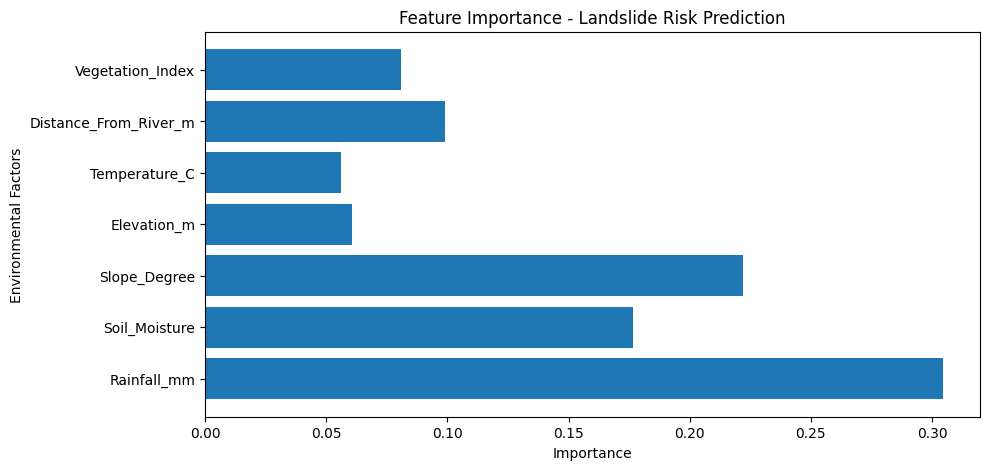

In [41]:
import matplotlib.pyplot as plt

features = [
    "Rainfall_mm",
        "Soil_Moisture",
            "Slope_Degree",
                "Elevation_m",
                    "Temperature_C",
                        "Distance_From_River_m",
                            "Vegetation_Index"
                            ]
importance = model.feature_importances_

plt.figure(figsize=(10, 5))
plt.barh(features, importance)
plt.xlabel("Importance")
plt.ylabel("Environmental Factors")
plt.title("Feature Importance - Landslide Risk Prediction")
plt.show()

In [42]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 88.5 %

Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.83      0.89        60
         Low       1.00      0.45      0.62        20
      Medium       0.85      0.98      0.91       120

    accuracy                           0.89       200
   macro avg       0.94      0.76      0.81       200
weighted avg       0.90      0.89      0.88       200



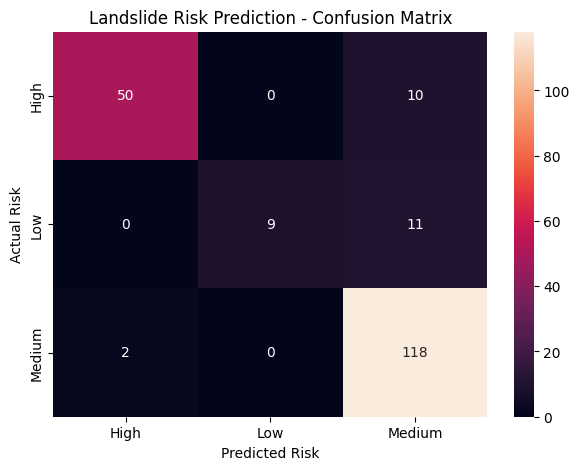

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
        annot=True,
            fmt="d",
                xticklabels=model.classes_,
                    yticklabels=model.classes_
                    )

plt.xlabel("Predicted Risk")
plt.ylabel("Actual Risk")
plt.title("Landslide Risk Prediction - Confusion Matrix")

plt.show()

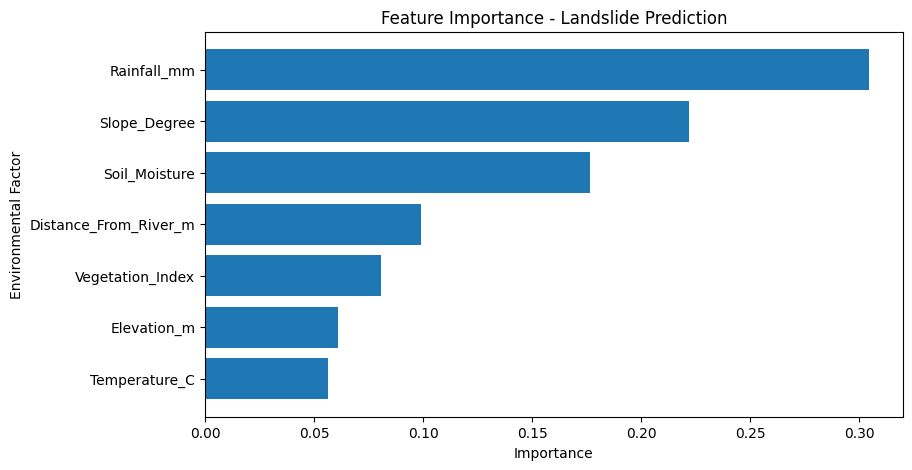

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
        "Importance": model.feature_importances_
        })

feature_importance = feature_importance.sort_values(
            "Importance",
                ascending=False
                )

plt.figure(figsize=(9, 5))

plt.barh(
                    feature_importance["Feature"],
                        feature_importance["Importance"]
                        )

plt.xlabel("Importance")
plt.ylabel("Environmental Factor")
plt.title("Feature Importance - Landslide Prediction")

plt.gca().invert_yaxis()

plt.show()

In [45]:
import joblib

joblib.dump(model, "landslide_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [46]:
from google.colab import files

files.download("landslide_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>